In [1]:
# ============================================================
# CELL 0 — Setup
# Part 2: RESEARCH-LEVEL Linear Regression vs XGBoost
# Target: Predict tomorrow's green tea leaf price (LKR/kg)
# ============================================================

import os
os.makedirs('plots/part2', exist_ok=True)
os.makedirs('results',     exist_ok=True)

print("="*62)
print("   🎓 RESEARCH-LEVEL REGRESSION COMPARISON")
print("="*62)
print()
print("   This notebook performs 6 pillars of rigorous analysis:")
print()
print("   PILLAR 1: Naive baseline benchmark")
print("   PILLAR 2: Hyperparameter tuning (fair comparison)")
print("   PILLAR 3: Time-Series Cross-Validation (5 folds)")
print("   PILLAR 4: Diebold-Mariano significance test")
print("   PILLAR 5: Residual analysis")
print("   PILLAR 6: Feature importance interpretation")
print()
print("   This makes the comparison publication-quality.")
print()
print("✅ Setup complete! Ready for Cell 1!")

   🎓 RESEARCH-LEVEL REGRESSION COMPARISON

   This notebook performs 6 pillars of rigorous analysis:

   PILLAR 1: Naive baseline benchmark
   PILLAR 2: Hyperparameter tuning (fair comparison)
   PILLAR 3: Time-Series Cross-Validation (5 folds)
   PILLAR 4: Diebold-Mariano significance test
   PILLAR 5: Residual analysis
   PILLAR 6: Feature importance interpretation

   This makes the comparison publication-quality.

✅ Setup complete! Ready for Cell 1!


In [2]:
# ============================================================
# CELL 1 — Import All Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LinearRegression
import xgboost as xgb

# Model selection and validation
from sklearn.model_selection import (TimeSeriesSplit,
                                     GridSearchCV)
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)

# Statistics
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')

print("="*55)
print("   ✅ ALL LIBRARIES IMPORTED!")
print("="*55)
print(f"   xgboost : {xgb.__version__}")
import sklearn
print(f"   sklearn : {sklearn.__version__}")
import scipy
print(f"   scipy   : {scipy.__version__}")
print("="*55)
print("✅ Ready for Cell 2!")

   ✅ ALL LIBRARIES IMPORTED!
   xgboost : 3.2.0
   sklearn : 1.9.0
   scipy   : 1.17.1
✅ Ready for Cell 2!


In [3]:
# ============================================================
# CELL 2 — Load and Inspect Dataset
# ============================================================

df = pd.read_csv('data/tea_price_regression.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("="*60)
print("   📊 DATASET OVERVIEW")
print("="*60)
print(f"   File     : tea_price_regression.csv")
print(f"   Rows     : {len(df):,}")
print(f"   Columns  : {len(df.columns)}")
print(f"   Period   : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"   Missing  : {df.isnull().sum().sum()}")
print()
print("   Prediction target: NextDayGreenLeafPrice")
print()
print("📋 Target variable statistics:")
print(df['NextDayGreenLeafPrice'].describe().round(2))
print()
print("📋 First 5 rows (key columns):")
print(df[['Date',
          'GreenLeafPricePerKgLKR',
          'PriceLag1',
          'RainfallMM',
          'NextDayGreenLeafPrice']].head())
print()
print("✅ Data loaded! Ready for Cell 3!")

   📊 DATASET OVERVIEW
   File     : tea_price_regression.csv
   Rows     : 1,065
   Columns  : 33
   Period   : 2021-01-30 → 2023-12-30
   Missing  : 0

   Prediction target: NextDayGreenLeafPrice

📋 Target variable statistics:
count    1065.00
mean      101.93
std         9.57
min        79.49
25%        94.89
50%       100.93
75%       107.29
max       131.88
Name: NextDayGreenLeafPrice, dtype: float64

📋 First 5 rows (key columns):
        Date  GreenLeafPricePerKgLKR  PriceLag1  RainfallMM  \
0 2021-01-30                   93.28      97.39         4.5   
1 2021-01-31                   90.26      93.28         1.9   
2 2021-02-01                   93.29      90.26         5.6   
3 2021-02-02                   98.30      93.29         2.5   
4 2021-02-03                   99.73      98.30         1.4   

   NextDayGreenLeafPrice  
0                  90.26  
1                  93.29  
2                  98.30  
3                  99.73  
4                  97.71  

✅ Data loaded! Read

In [4]:
# ============================================================
# CELL 3 — Define Features (X) and Target (y)
# ============================================================

feature_columns = [
    # Calendar
    'Month', 'DayOfWeek', 'Quarter',
    'IsWeekend', 'DayOfYear', 'Day',
    # Price history (most important)
    'GreenLeafPricePerKgLKR',
    'PriceLag1', 'PriceLag2', 'PriceLag3',
    'PriceLag7', 'PriceLag14',
    'PriceRollingMean7', 'PriceRollingMean30',
    'PriceRollingStd7', 'PriceChangePct',
    # Quantity
    'GreenLeafQuantityKg', 'QtyRollingMean7',
    # Costs
    'FirewoodCollectedKg', 'FirewoodCostPerKgLKR',
    'TotalDailyCostLKR',
    # Weather
    'TemperatureCelsius', 'RainfallMM', 'HeavyRainFlag',
    # Business
    'SupplierDelivered', 'SupplierQuantityKg',
    'PromotionActive', 'MonthStartBonus',
]

TARGET = 'NextDayGreenLeafPrice'

X = df[feature_columns].copy()
y = df[TARGET].copy()

print("="*60)
print("   📊 FEATURES AND TARGET DEFINED")
print("="*60)
print(f"   Number of features : {len(feature_columns)}")
print(f"   Total samples      : {len(X):,}")
print(f"   Target             : {TARGET}")
print()
print(f"   Target range : {y.min():.2f} → {y.max():.2f} LKR/kg")
print(f"   Target mean  : {y.mean():.2f} LKR/kg")
print()
print("✅ Ready for Cell 4!")

   📊 FEATURES AND TARGET DEFINED
   Number of features : 28
   Total samples      : 1,065
   Target             : NextDayGreenLeafPrice

   Target range : 79.49 → 131.88 LKR/kg
   Target mean  : 101.93 LKR/kg

✅ Ready for Cell 4!


In [5]:
# ============================================================
# CELL 4 — Chronological Split and Metric Function
#
# We split by TIME (not random) because this is time series.
# 80% train, 20% test.
# ============================================================

SPLIT_RATIO = 0.80
split_idx   = int(len(X) * SPLIT_RATIO)

X_train = X.iloc[:split_idx].reset_index(drop=True)
X_test  = X.iloc[split_idx:].reset_index(drop=True)
y_train = y.iloc[:split_idx].reset_index(drop=True)
y_test  = y.iloc[split_idx:].reset_index(drop=True)

dates_train = df['Date'].iloc[:split_idx].reset_index(drop=True)
dates_test  = df['Date'].iloc[split_idx:].reset_index(drop=True)

# Scale features for Linear Regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


# ---- Universal metric function ----
def compute_metrics(actual, predicted, model_name):
    """Returns MAE, RMSE, MAPE, R2 in a dictionary"""
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2   = r2_score(actual, predicted)
    return {'Model': model_name,
            'MAE':  round(mae, 4),
            'RMSE': round(rmse, 4),
            'MAPE': round(mape, 4),
            'R2':   round(r2, 4)}


print("="*60)
print("   📊 TRAIN / TEST SPLIT")
print("="*60)
print(f"   Training : {len(X_train):,} samples "
      f"({dates_train.min().date()} → {dates_train.max().date()})")
print(f"   Testing  : {len(X_test):,} samples "
      f"({dates_test.min().date()} → {dates_test.max().date()})")
print()
print("✅ Data split and scaled!")
print("✅ Metric function ready!")
print("✅ Ready for Cell 5 (PILLAR 1)!")

   📊 TRAIN / TEST SPLIT
   Training : 852 samples (2021-01-30 → 2023-05-31)
   Testing  : 213 samples (2023-06-01 → 2023-12-30)

✅ Data split and scaled!
✅ Metric function ready!
✅ Ready for Cell 5 (PILLAR 1)!


In [6]:
# ============================================================
# CELL 5 — PILLAR 1: NAIVE BASELINE BENCHMARK
#
# WHAT IS A NAIVE BASELINE?
# The simplest possible prediction:
#   "Tomorrow's price = Today's price"
#
# WHY DO WE NEED IT?
# If our fancy models cannot beat this simple guess,
# then they are WORTHLESS. Every research paper includes
# a baseline to prove the models actually add value.
# ============================================================

print("="*60)
print("   🎯 PILLAR 1: NAIVE BASELINE")
print("="*60)
print()
print("   Naive rule: Tomorrow's price = Today's price")
print()

# Naive prediction = today's price (the feature we know)
naive_pred = X_test['GreenLeafPricePerKgLKR'].values

naive_metrics = compute_metrics(y_test.values,
                                naive_pred,
                                'Naive Baseline')

print(f"   📊 Naive Baseline Performance:")
print(f"      MAE  : {naive_metrics['MAE']:.4f} LKR/kg")
print(f"      RMSE : {naive_metrics['RMSE']:.4f} LKR/kg")
print(f"      MAPE : {naive_metrics['MAPE']:.4f} %")
print(f"      R²   : {naive_metrics['R2']:.4f}")
print()
print("   📖 INTERPRETATION:")
print("      This is the score our models MUST beat.")
print("      Linear Regression and XGBoost should both")
print("      achieve LOWER error than this baseline,")
print("      otherwise they add no value.")
print()
print("✅ Baseline established! Ready for Cell 6!")

   🎯 PILLAR 1: NAIVE BASELINE

   Naive rule: Tomorrow's price = Today's price

   📊 Naive Baseline Performance:
      MAE  : 3.9511 LKR/kg
      RMSE : 4.7598 LKR/kg
      MAPE : 3.8485 %
      R²   : 0.6946

   📖 INTERPRETATION:
      This is the score our models MUST beat.
      Linear Regression and XGBoost should both
      achieve LOWER error than this baseline,
      otherwise they add no value.

✅ Baseline established! Ready for Cell 6!


In [7]:
# ============================================================
# CELL 6 — Train Linear Regression
#
# Linear Regression has no real hyperparameters to tune.
# It simply finds the best-fit straight-line relationship.
# This is our INTERPRETABLE baseline model.
# ============================================================

print("="*60)
print("   🔄 TRAINING LINEAR REGRESSION")
print("="*60)

lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

lr_pred_test = lr_model.predict(X_test_sc)

lr_metrics = compute_metrics(y_test.values,
                             lr_pred_test,
                             'Linear Regression')

print()
print(f"   📊 Linear Regression Performance:")
print(f"      MAE  : {lr_metrics['MAE']:.4f} LKR/kg")
print(f"      RMSE : {lr_metrics['RMSE']:.4f} LKR/kg")
print(f"      MAPE : {lr_metrics['MAPE']:.4f} %")
print(f"      R²   : {lr_metrics['R2']:.4f}")
print()

# Compare vs baseline
improvement = ((naive_metrics['MAE'] - lr_metrics['MAE'])
               / naive_metrics['MAE'] * 100)
print(f"   vs Naive baseline:")
if lr_metrics['MAE'] < naive_metrics['MAE']:
    print(f"      ✅ Beats baseline by {improvement:.1f}% (MAE)")
else:
    print(f"      ⚠️  Does NOT beat baseline")
print()
print("✅ Linear Regression trained! Ready for Cell 7!")

   🔄 TRAINING LINEAR REGRESSION

   📊 Linear Regression Performance:
      MAE  : 3.1030 LKR/kg
      RMSE : 3.8120 LKR/kg
      MAPE : 2.9943 %
      R²   : 0.8041

   vs Naive baseline:
      ✅ Beats baseline by 21.5% (MAE)

✅ Linear Regression trained! Ready for Cell 7!


In [8]:
# ============================================================
# CELL 7 — PILLAR 2: XGBOOST HYPERPARAMETER TUNING
#
# WHAT IS HYPERPARAMETER TUNING?
# XGBoost has many settings (how many trees, how deep,
# how fast to learn, etc.). Default settings are rarely best.
#
# We use GridSearchCV to try many combinations and find
# the BEST settings automatically.
#
# WHY TimeSeriesSplit?
# Normal cross-validation shuffles data randomly.
# But we CANNOT use future data to predict the past!
# TimeSeriesSplit respects time order.
#
# ⏳ THIS TAKES 3-8 MINUTES — please wait
# ============================================================

print("="*60)
print("   🔄 PILLAR 2: XGBOOST HYPERPARAMETER TUNING")
print("="*60)
print()
print("   Testing many parameter combinations...")
print("   Using 5-fold Time-Series Cross-Validation")
print("   ⏳ This takes 3-8 minutes. Please wait.")
print()

# Parameter grid to search
param_grid = {
    'n_estimators':  [200, 400],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample':     [0.8, 1.0],
}

# Time series cross-validation (respects time order)
tscv = TimeSeriesSplit(n_splits=5)

# Base model
xgb_base = xgb.XGBRegressor(
    random_state=42,
    verbosity=0,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0
)

# Grid search
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print()
print("="*60)
print("   ✅ BEST PARAMETERS FOUND!")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"      {param:<15} : {value}")
print()
print(f"   Best CV score (MAE): {-grid_search.best_score_:.4f}")
print()

# Use the best model
xgb_model = grid_search.best_estimator_

print("✅ XGBoost tuned! Ready for Cell 8!")

   🔄 PILLAR 2: XGBOOST HYPERPARAMETER TUNING

   Testing many parameter combinations...
   Using 5-fold Time-Series Cross-Validation
   ⏳ This takes 3-8 minutes. Please wait.

Fitting 5 folds for each of 36 candidates, totalling 180 fits

   ✅ BEST PARAMETERS FOUND!
      learning_rate   : 0.03
      max_depth       : 3
      n_estimators    : 200
      subsample       : 1.0

   Best CV score (MAE): 5.2665

✅ XGBoost tuned! Ready for Cell 8!


In [9]:
# ============================================================
# CELL 8 — Evaluate the Tuned XGBoost Model
# ============================================================

print("="*60)
print("   📊 EVALUATING TUNED XGBOOST")
print("="*60)

xgb_pred_test = xgb_model.predict(X_test)

xgb_metrics = compute_metrics(y_test.values,
                              xgb_pred_test,
                              'XGBoost (tuned)')

print()
print(f"   📊 XGBoost Performance:")
print(f"      MAE  : {xgb_metrics['MAE']:.4f} LKR/kg")
print(f"      RMSE : {xgb_metrics['RMSE']:.4f} LKR/kg")
print(f"      MAPE : {xgb_metrics['MAPE']:.4f} %")
print(f"      R²   : {xgb_metrics['R2']:.4f}")
print()

# Compare vs baseline
xgb_improvement = ((naive_metrics['MAE'] - xgb_metrics['MAE'])
                   / naive_metrics['MAE'] * 100)
print(f"   vs Naive baseline:")
if xgb_metrics['MAE'] < naive_metrics['MAE']:
    print(f"      ✅ Beats baseline by {xgb_improvement:.1f}% (MAE)")
else:
    print(f"      ⚠️  Does NOT beat baseline")
print()
print("✅ XGBoost evaluated! Ready for Cell 9!")

   📊 EVALUATING TUNED XGBOOST

   📊 XGBoost Performance:
      MAE  : 3.6194 LKR/kg
      RMSE : 4.5918 LKR/kg
      MAPE : 3.4631 %
      R²   : 0.7158

   vs Naive baseline:
      ✅ Beats baseline by 8.4% (MAE)

✅ XGBoost evaluated! Ready for Cell 9!


In [10]:
# ============================================================
# CELL 9 — PILLAR 3: TIME-SERIES CROSS-VALIDATION
#
# WHY THIS MATTERS:
# Testing on just ONE test set might be lucky.
# We test on 5 DIFFERENT time folds and average results.
# This is the regression equivalent of your Part 1
# walk-forward validation — it proves consistency.
#
# ⏳ Takes 1-3 minutes
# ============================================================

print("="*60)
print("   🔄 PILLAR 3: TIME-SERIES CROSS-VALIDATION (5 folds)")
print("="*60)
print()

tscv_eval = TimeSeriesSplit(n_splits=5)

# Storage
cv_results = {'Linear Regression': [], 'XGBoost': []}

fold_num = 0
for train_idx, test_idx in tscv_eval.split(X):
    fold_num += 1

    # Split this fold
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # --- Linear Regression (scaled) ---
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    lr_fold = LinearRegression()
    lr_fold.fit(X_tr_sc, y_tr)
    lr_fold_pred = lr_fold.predict(X_te_sc)
    lr_fold_mape = np.mean(
        np.abs((y_te.values - lr_fold_pred) / y_te.values)) * 100

    # --- XGBoost (best params) ---
    xgb_fold = xgb.XGBRegressor(
        **grid_search.best_params_,
        random_state=42, verbosity=0,
        colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0
    )
    xgb_fold.fit(X_tr, y_tr)
    xgb_fold_pred = xgb_fold.predict(X_te)
    xgb_fold_mape = np.mean(
        np.abs((y_te.values - xgb_fold_pred) / y_te.values)) * 100

    cv_results['Linear Regression'].append(lr_fold_mape)
    cv_results['XGBoost'].append(xgb_fold_mape)

    print(f"   Fold {fold_num}: "
          f"LR MAPE = {lr_fold_mape:6.3f}%  |  "
          f"XGB MAPE = {xgb_fold_mape:6.3f}%  |  "
          f"{'XGB' if xgb_fold_mape < lr_fold_mape else 'LR'} wins")

# Averages
lr_cv_mean  = np.mean(cv_results['Linear Regression'])
lr_cv_std   = np.std(cv_results['Linear Regression'])
xgb_cv_mean = np.mean(cv_results['XGBoost'])
xgb_cv_std  = np.std(cv_results['XGBoost'])

print()
print("="*60)
print("   📊 CROSS-VALIDATION SUMMARY (5 folds)")
print("="*60)
print(f"   Linear Regression: {lr_cv_mean:.3f}% ± {lr_cv_std:.3f}%")
print(f"   XGBoost          : {xgb_cv_mean:.3f}% ± {xgb_cv_std:.3f}%")
print()
cv_winner = 'XGBoost' if xgb_cv_mean < lr_cv_mean else 'Linear Regression'
print(f"   🏆 CV Winner (lower avg MAPE): {cv_winner}")
print(f"   More consistent (lower std): "
      f"{'XGBoost' if xgb_cv_std < lr_cv_std else 'Linear Regression'}")
print()
print("✅ Cross-validation done! Ready for Cell 10!")

   🔄 PILLAR 3: TIME-SERIES CROSS-VALIDATION (5 folds)

   Fold 1: LR MAPE = 12.027%  |  XGB MAPE =  9.297%  |  XGB wins
   Fold 2: LR MAPE =  4.034%  |  XGB MAPE =  5.998%  |  LR wins
   Fold 3: LR MAPE =  3.584%  |  XGB MAPE =  3.627%  |  LR wins
   Fold 4: LR MAPE =  3.365%  |  XGB MAPE =  3.565%  |  LR wins
   Fold 5: LR MAPE =  2.977%  |  XGB MAPE =  3.299%  |  LR wins

   📊 CROSS-VALIDATION SUMMARY (5 folds)
   Linear Regression: 5.197% ± 3.432%
   XGBoost          : 5.157% ± 2.288%

   🏆 CV Winner (lower avg MAPE): XGBoost
   More consistent (lower std): XGBoost

✅ Cross-validation done! Ready for Cell 10!


In [11]:
# ============================================================
# CELL 10 — PILLAR 4: DIEBOLD-MARIANO SIGNIFICANCE TEST
#
# THE MOST IMPORTANT RESEARCH STEP!
#
# Question: "XGBoost has lower error — but is the difference
#            REAL, or could it be random luck?"
#
# The Diebold-Mariano test answers this scientifically.
#
# How to read the result:
#   p-value < 0.05 → The difference IS statistically
#                    significant (REAL difference) ✅
#   p-value > 0.05 → The difference might be due to chance ⚠️
# ============================================================

print("="*60)
print("   🔬 PILLAR 4: STATISTICAL SIGNIFICANCE TEST")
print("="*60)
print()

# Calculate forecast errors on the test set
lr_errors  = y_test.values - lr_pred_test
xgb_errors = y_test.values - xgb_pred_test

# Squared errors (loss differential)
lr_sq  = lr_errors ** 2
xgb_sq = xgb_errors ** 2

# Loss differential
d = lr_sq - xgb_sq   # positive = LR worse = XGBoost better

def diebold_mariano(d):
    """Simple Diebold-Mariano test (h=1 forecast horizon)"""
    mean_d = np.mean(d)
    n      = len(d)
    var_d  = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / n)
    # Two-sided p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

dm_stat, p_value = diebold_mariano(d)

print(f"   Comparing: Linear Regression vs XGBoost")
print(f"   (based on squared forecast errors)")
print()
print(f"   DM statistic : {dm_stat:.4f}")
print(f"   p-value      : {p_value:.6f}")
print()
print("   📖 INTERPRETATION:")
if p_value < 0.05:
    better = 'XGBoost' if np.mean(d) > 0 else 'Linear Regression'
    print(f"      ✅ p-value < 0.05 → STATISTICALLY SIGNIFICANT")
    print(f"      The difference is REAL, not random chance.")
    print(f"      {better} is genuinely the better model.")
else:
    print(f"      ⚠️  p-value > 0.05 → NOT statistically significant")
    print(f"      The two models perform similarly.")
    print(f"      The difference could be due to chance.")
print()
print("   This is the gold-standard test used in")
print("   forecasting research papers.")
print()
print("✅ Significance test done! Ready for Cell 11!")

   🔬 PILLAR 4: STATISTICAL SIGNIFICANCE TEST

   Comparing: Linear Regression vs XGBoost
   (based on squared forecast errors)

   DM statistic : -3.8706
   p-value      : 0.000109

   📖 INTERPRETATION:
      ✅ p-value < 0.05 → STATISTICALLY SIGNIFICANT
      The difference is REAL, not random chance.
      Linear Regression is genuinely the better model.

   This is the gold-standard test used in
   forecasting research papers.

✅ Significance test done! Ready for Cell 11!


   📊 PILLAR 5: RESIDUAL ANALYSIS


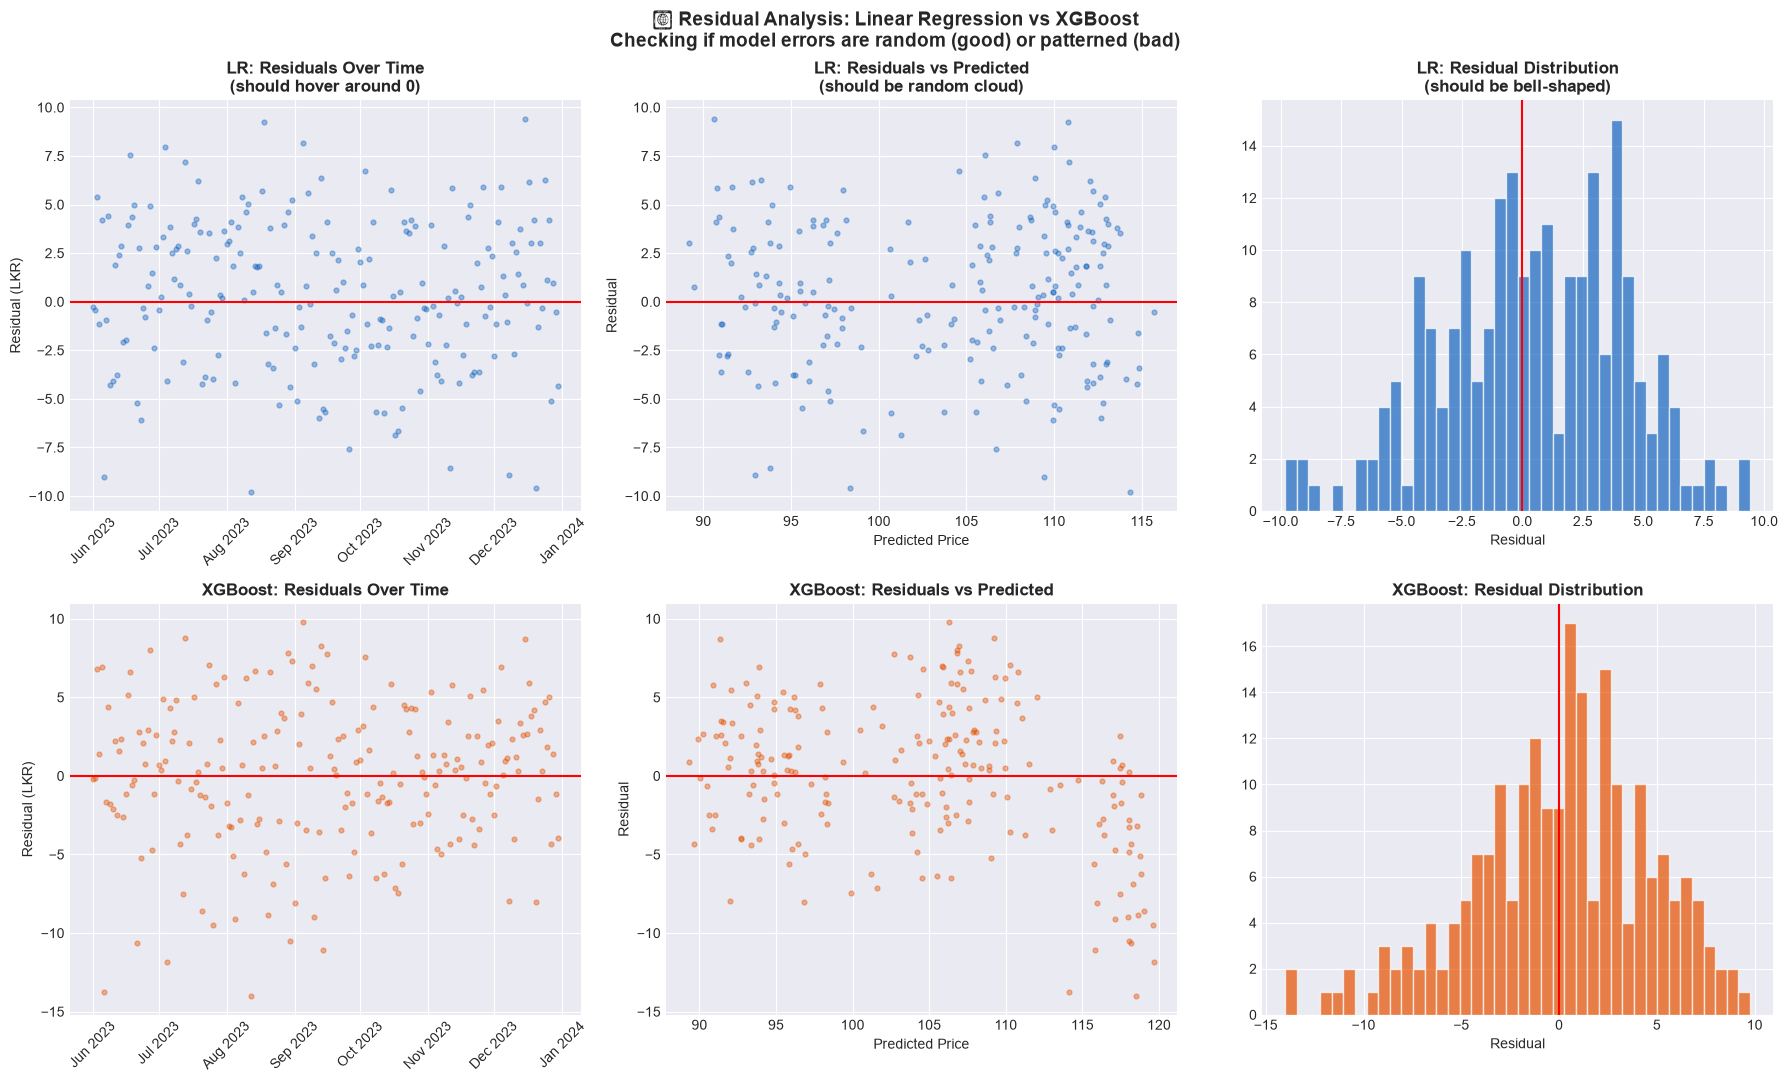


   Residual Statistics:
   Metric                   Linear Reg        XGBoost
   ──────────────────────────────────────────────────
   Mean (bias)                  0.3989         0.0357
   Std deviation                3.7911         4.5916
   Max error                    9.8118        14.0087

   📖 INTERPRETATION:
   → Mean near 0 = no systematic bias (good)
   → Lower std = more precise predictions

✅ Residual analysis done! Ready for Cell 12!


In [12]:
# ============================================================
# CELL 11 — PILLAR 5: RESIDUAL ANALYSIS
#
# WHAT ARE RESIDUALS?
# Residual = Actual price - Predicted price (the errors)
#
# GOOD model residuals should be:
#   ✅ Centered around zero (no systematic bias)
#   ✅ Randomly scattered (no leftover pattern)
#   ✅ Normally distributed (bell shape)
#
# If residuals have a PATTERN, the model is missing something.
# ============================================================

print("="*60)
print("   📊 PILLAR 5: RESIDUAL ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    '📊 Residual Analysis: Linear Regression vs XGBoost\n'
    'Checking if model errors are random (good) or patterned (bad)',
    fontsize=14, fontweight='bold'
)

# Row 1: Linear Regression
# --- Residuals over time ---
axes[0][0].scatter(dates_test.values, lr_errors,
                   alpha=0.4, color='#1565C0', s=12)
axes[0][0].axhline(y=0, color='red', linewidth=1.5)
axes[0][0].set_title('LR: Residuals Over Time\n(should hover around 0)',
                     fontweight='bold')
axes[0][0].set_ylabel('Residual (LKR)')

# --- Residuals vs predicted ---
axes[0][1].scatter(lr_pred_test, lr_errors,
                   alpha=0.4, color='#1565C0', s=12)
axes[0][1].axhline(y=0, color='red', linewidth=1.5)
axes[0][1].set_title('LR: Residuals vs Predicted\n(should be random cloud)',
                     fontweight='bold')
axes[0][1].set_xlabel('Predicted Price')
axes[0][1].set_ylabel('Residual')

# --- Histogram ---
axes[0][2].hist(lr_errors, bins=40, color='#1565C0',
                alpha=0.7, edgecolor='white')
axes[0][2].axvline(x=0, color='red', linewidth=1.5)
axes[0][2].set_title('LR: Residual Distribution\n(should be bell-shaped)',
                     fontweight='bold')
axes[0][2].set_xlabel('Residual')

# Row 2: XGBoost
axes[1][0].scatter(dates_test.values, xgb_errors,
                   alpha=0.4, color='#E65100', s=12)
axes[1][0].axhline(y=0, color='red', linewidth=1.5)
axes[1][0].set_title('XGBoost: Residuals Over Time',
                     fontweight='bold')
axes[1][0].set_ylabel('Residual (LKR)')

axes[1][1].scatter(xgb_pred_test, xgb_errors,
                   alpha=0.4, color='#E65100', s=12)
axes[1][1].axhline(y=0, color='red', linewidth=1.5)
axes[1][1].set_title('XGBoost: Residuals vs Predicted',
                     fontweight='bold')
axes[1][1].set_xlabel('Predicted Price')
axes[1][1].set_ylabel('Residual')

axes[1][2].hist(xgb_errors, bins=40, color='#E65100',
                alpha=0.7, edgecolor='white')
axes[1][2].axvline(x=0, color='red', linewidth=1.5)
axes[1][2].set_title('XGBoost: Residual Distribution',
                     fontweight='bold')
axes[1][2].set_xlabel('Residual')

for ax in [axes[0][0], axes[1][0]]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('plots/part2/P05_residual_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Statistical summary
print()
print("   Residual Statistics:")
print(f"   {'Metric':<20} {'Linear Reg':>14} {'XGBoost':>14}")
print(f"   {'─'*50}")
print(f"   {'Mean (bias)':<20} {np.mean(lr_errors):>14.4f} {np.mean(xgb_errors):>14.4f}")
print(f"   {'Std deviation':<20} {np.std(lr_errors):>14.4f} {np.std(xgb_errors):>14.4f}")
print(f"   {'Max error':<20} {np.max(np.abs(lr_errors)):>14.4f} {np.max(np.abs(xgb_errors)):>14.4f}")
print()
print("   📖 INTERPRETATION:")
print("   → Mean near 0 = no systematic bias (good)")
print("   → Lower std = more precise predictions")
print()
print("✅ Residual analysis done! Ready for Cell 12!")

   📊 PILLAR 6: FEATURE IMPORTANCE


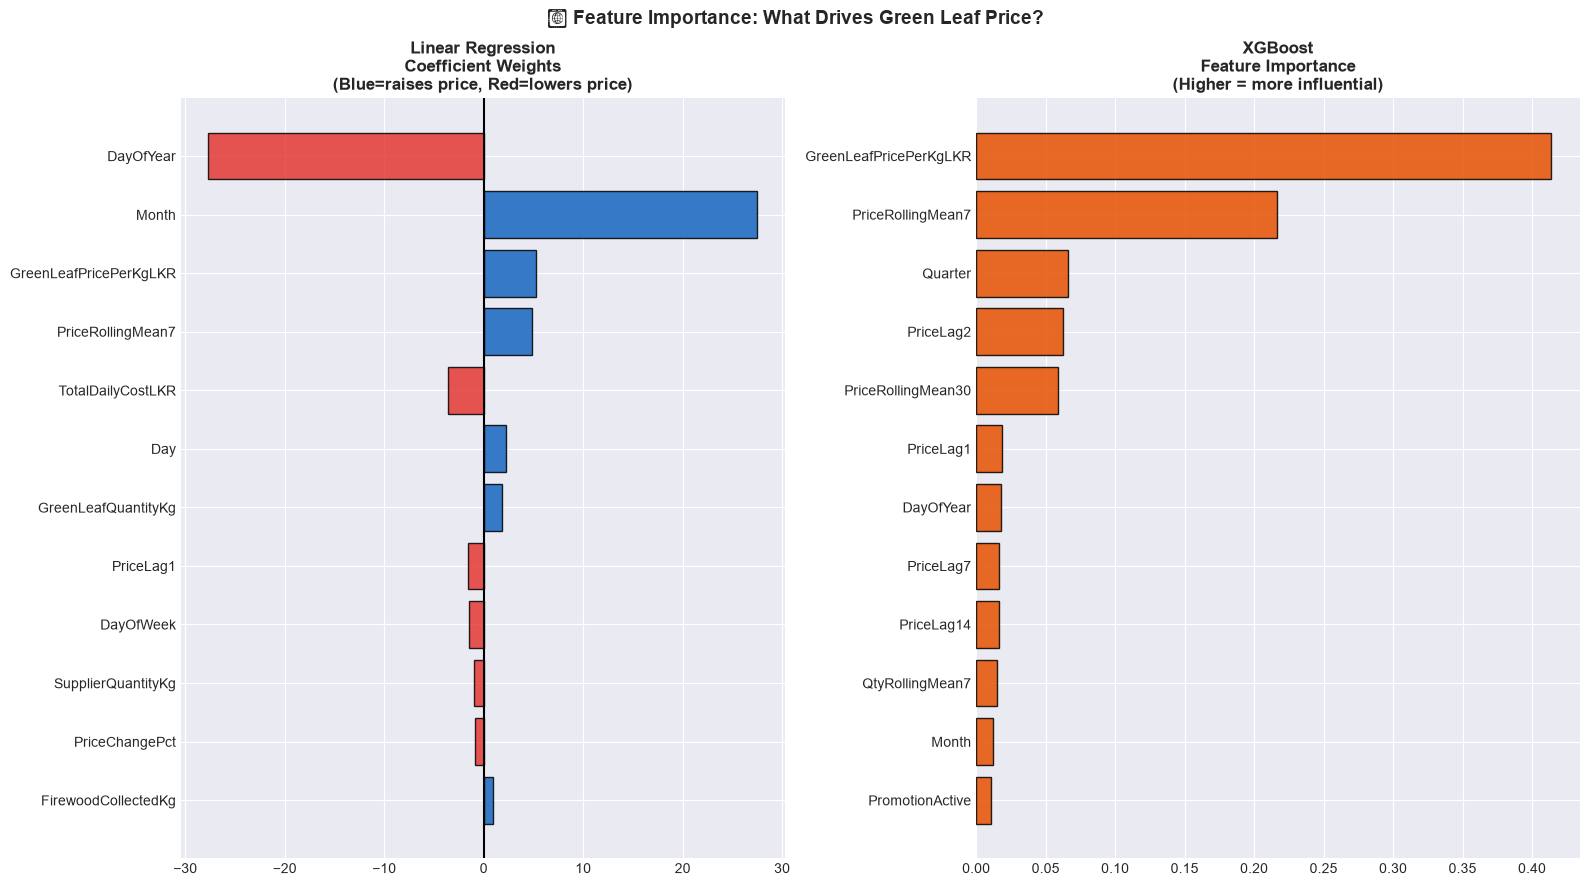


   Top 5 price drivers (XGBoost):
   1. GreenLeafPricePerKgLKR       (importance=0.4138)
   2. PriceRollingMean7            (importance=0.2166)
   3. Quarter                      (importance=0.0662)
   4. PriceLag2                    (importance=0.0622)
   5. PriceRollingMean30           (importance=0.0589)

✅ Feature importance done! Ready for Cell 13!


In [13]:
# ============================================================
# CELL 12 — PILLAR 6: FEATURE IMPORTANCE INTERPRETATION
#
# This explains WHICH factors drive green leaf price.
# Practical business insight for SmartTea.
# ============================================================

print("="*60)
print("   📊 PILLAR 6: FEATURE IMPORTANCE")
print("="*60)

# Linear Regression coefficients
lr_coef_df = pd.DataFrame({
    'Feature': feature_columns,
    'Weight':  lr_model.coef_
}).sort_values('Weight', key=abs, ascending=False)

# XGBoost importance
xgb_imp_df = pd.DataFrame({
    'Feature':    feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.suptitle(
    '📊 Feature Importance: What Drives Green Leaf Price?',
    fontsize=14, fontweight='bold'
)

top_lr = lr_coef_df.head(12)
colors_lr = ['#E53935' if w < 0 else '#1565C0'
             for w in top_lr['Weight']]
axes[0].barh(top_lr['Feature'], top_lr['Weight'],
             color=colors_lr, edgecolor='black', alpha=0.85)
axes[0].axvline(x=0, color='black', linewidth=1.5)
axes[0].set_title('Linear Regression\nCoefficient Weights\n'
                  '(Blue=raises price, Red=lowers price)',
                  fontweight='bold')
axes[0].invert_yaxis()

top_xgb = xgb_imp_df.head(12)
axes[1].barh(top_xgb['Feature'], top_xgb['Importance'],
             color='#E65100', edgecolor='black', alpha=0.85)
axes[1].set_title('XGBoost\nFeature Importance\n'
                  '(Higher = more influential)',
                  fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('plots/part2/P06_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print()
print("   Top 5 price drivers (XGBoost):")
for rank, (_, row) in enumerate(xgb_imp_df.head(5).iterrows(), 1):
    print(f"   {rank}. {row['Feature']:<28} "
          f"(importance={row['Importance']:.4f})")
print()
print("✅ Feature importance done! Ready for Cell 13!")

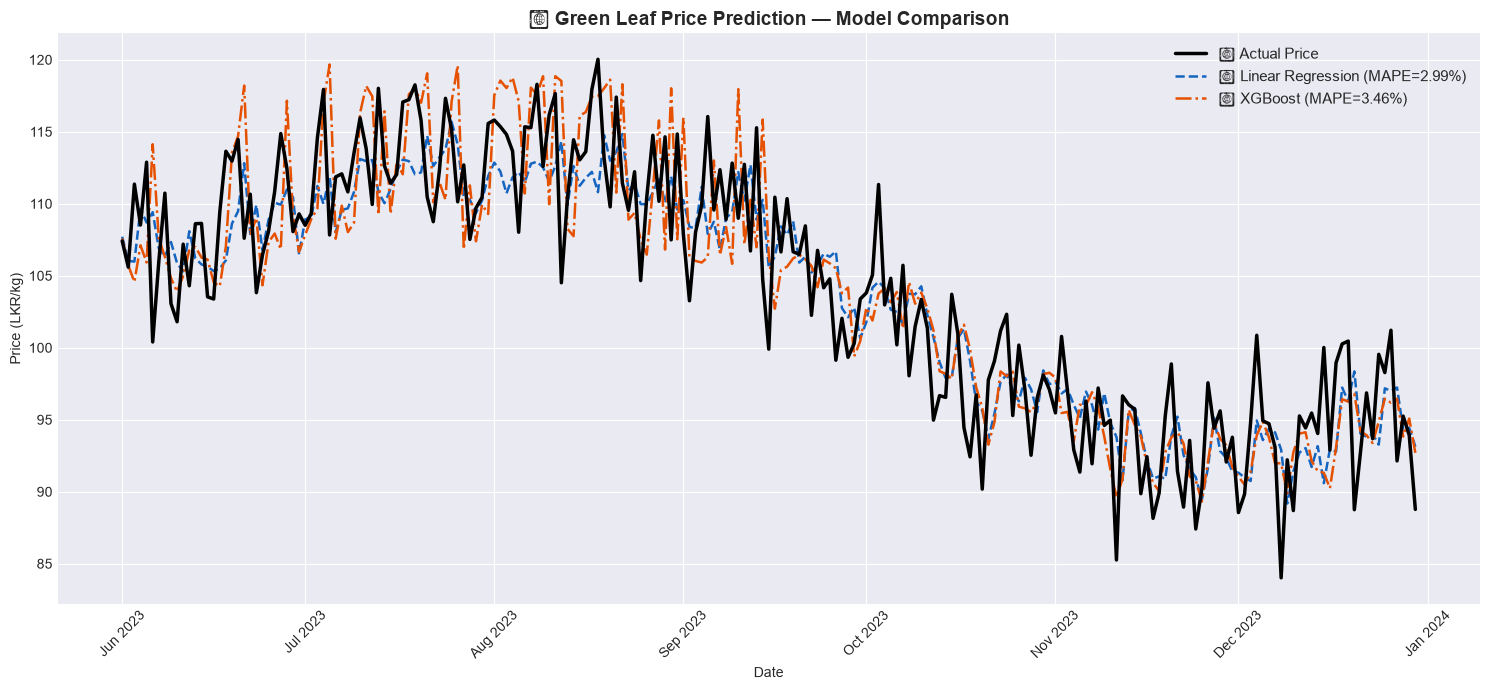

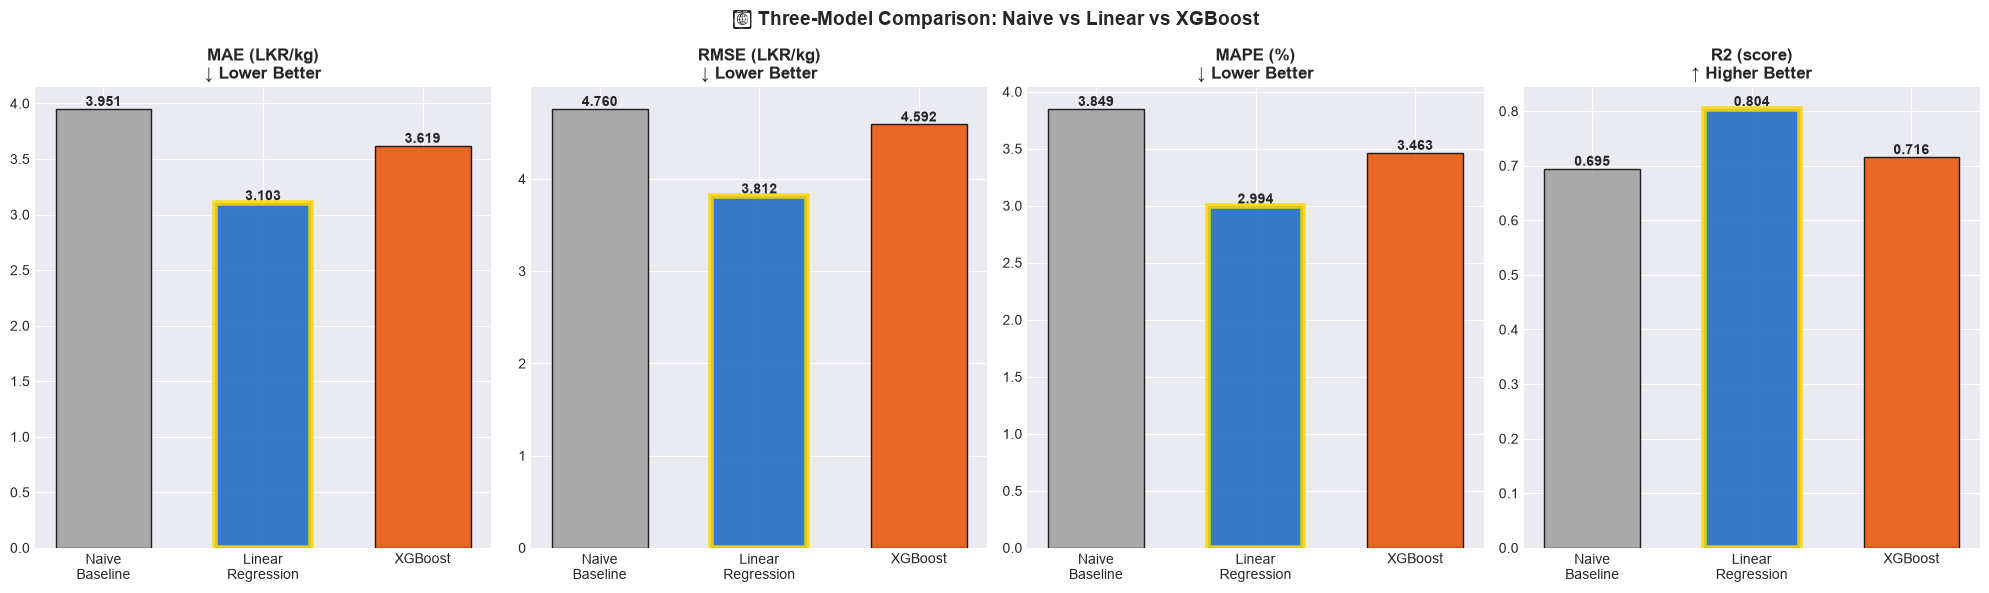

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

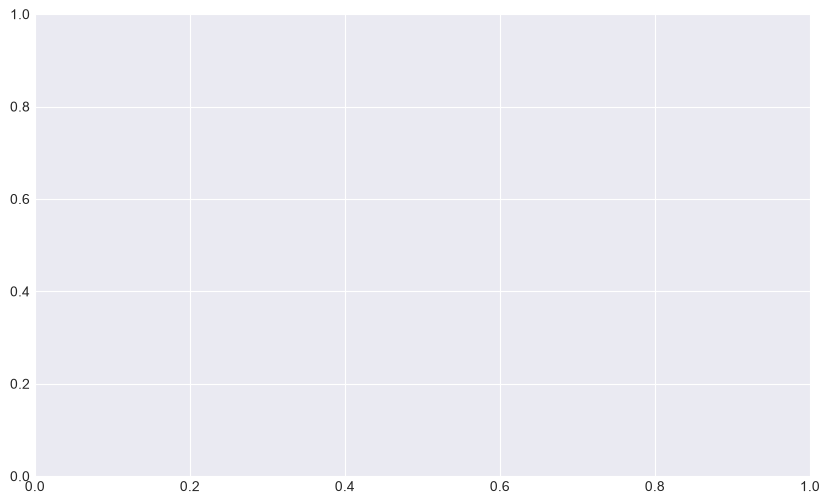

In [14]:
# ============================================================
# CELL 13 — Master Comparison Visualization
# ============================================================

# Combine all results
all_metrics = pd.DataFrame([naive_metrics, lr_metrics, xgb_metrics])
all_metrics = all_metrics.set_index('Model')

# ---- Chart 1: Predictions overlay ----
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(dates_test.values, y_test.values,
        color='black', linewidth=2.5,
        label='📦 Actual Price', zorder=6)
ax.plot(dates_test.values, lr_pred_test,
        color='#1565C0', linewidth=1.8, linestyle='--',
        label=f'📈 Linear Regression (MAPE={lr_metrics["MAPE"]:.2f}%)')
ax.plot(dates_test.values, xgb_pred_test,
        color='#E65100', linewidth=1.8, linestyle='-.',
        label=f'🌲 XGBoost (MAPE={xgb_metrics["MAPE"]:.2f}%)')
ax.set_title('📊 Green Leaf Price Prediction — Model Comparison',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (LKR/kg)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/part2/P07_predictions_overlay.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Chart 2: Metric bars (all 3 models) ----
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('📊 Three-Model Comparison: Naive vs Linear vs XGBoost',
             fontsize=14, fontweight='bold')

metrics_list  = ['MAE', 'RMSE', 'MAPE', 'R2']
units_list    = ['LKR/kg', 'LKR/kg', '%', 'score']
higher_better = [False, False, False, True]
model_names   = ['Naive\nBaseline', 'Linear\nRegression', 'XGBoost']
model_colors  = ['#9E9E9E', '#1565C0', '#E65100']

for i, (metric, unit, hb) in enumerate(
        zip(metrics_list, units_list, higher_better)):
    vals = [naive_metrics[metric],
            lr_metrics[metric],
            xgb_metrics[metric]]
    bars = axes[i].bar(model_names, vals,
                       color=model_colors,
                       edgecolor='black', alpha=0.85, width=0.6)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height(),
                     f'{val:.3f}',
                     ha='center', va='bottom',
                     fontweight='bold', fontsize=10)
    # Best model gets gold border
    if hb:
        best_idx = int(np.argmax(vals))
    else:
        best_idx = int(np.argmin(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(4)

    note = '↑ Higher Better' if hb else '↓ Lower Better'
    axes[i].set_title(f'{metric} ({unit})\n{note}',
                      fontweight='bold')

plt.tight_layout()
plt.savefig('plots/part2/P08_three_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ---- Chart 3: CV results boxplot ----
fig, ax = plt.subplots(figsize=(10, 6))
box_data = [cv_results['Linear Regression'],
            cv_results['XGBoost']]
bp = ax.boxplot(box_data,
                labels=['Linear Regression', 'XGBoost'],
                patch_artist=True,
                medianprops={'linewidth': 2.5, 'color': 'black'},
                widths=0.5)
bp['boxes'][0].set_facecolor('#1565C0')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#E65100')
bp['boxes'][1].set_alpha(0.7)
ax.scatter([1]*5, cv_results['Linear Regression'],
           color='darkblue', zorder=5, s=60)
ax.scatter([2]*5, cv_results['XGBoost'],
           color='darkred', zorder=5, s=60)
ax.set_title('📊 5-Fold Cross-Validation MAPE Distribution\n'
             '(Lower and tighter box = better and more consistent)',
             fontweight='bold')
ax.set_ylabel('MAPE (%)')
plt.tight_layout()
plt.savefig('plots/part2/P09_cv_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ All comparison charts saved!")
print("   → P07_predictions_overlay.png")
print("   → P08_three_model_comparison.png")
print("   → P09_cv_boxplot.png")
print("✅ Ready for Cell 14!")

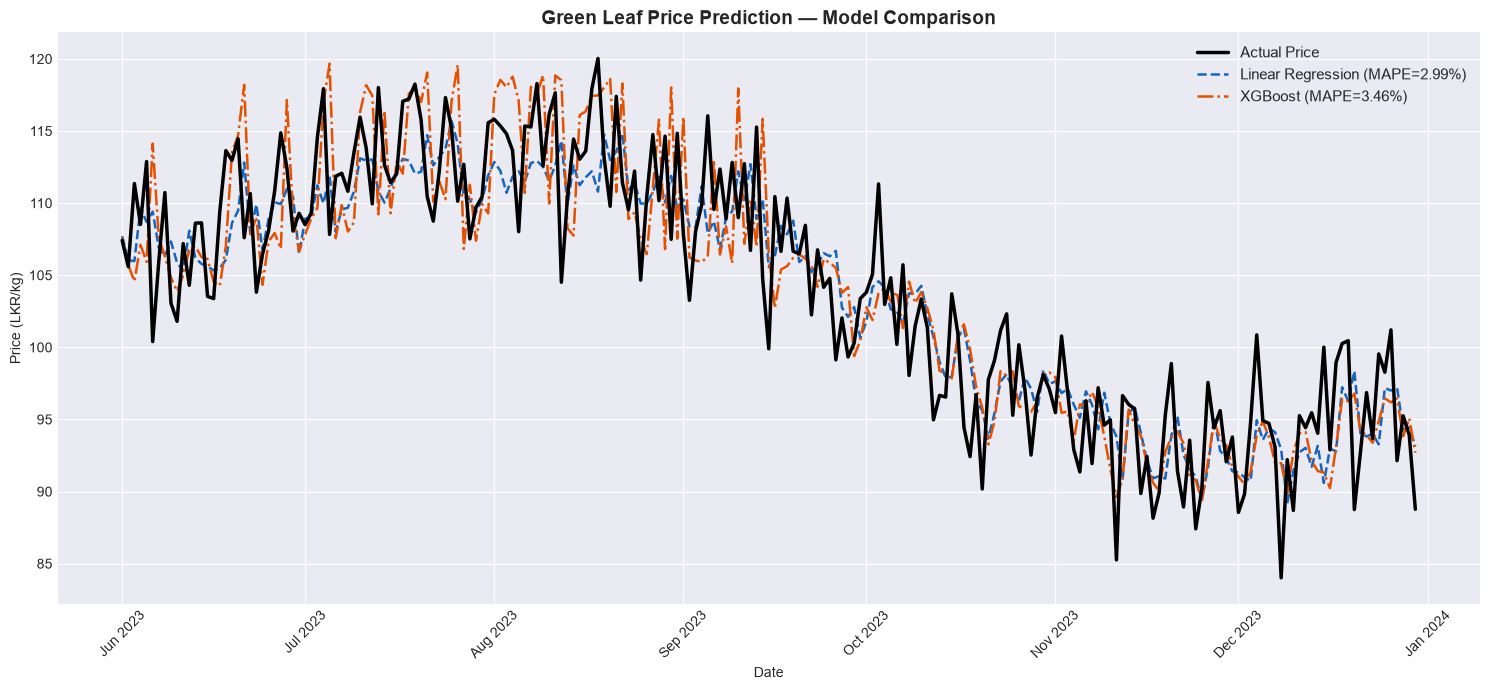

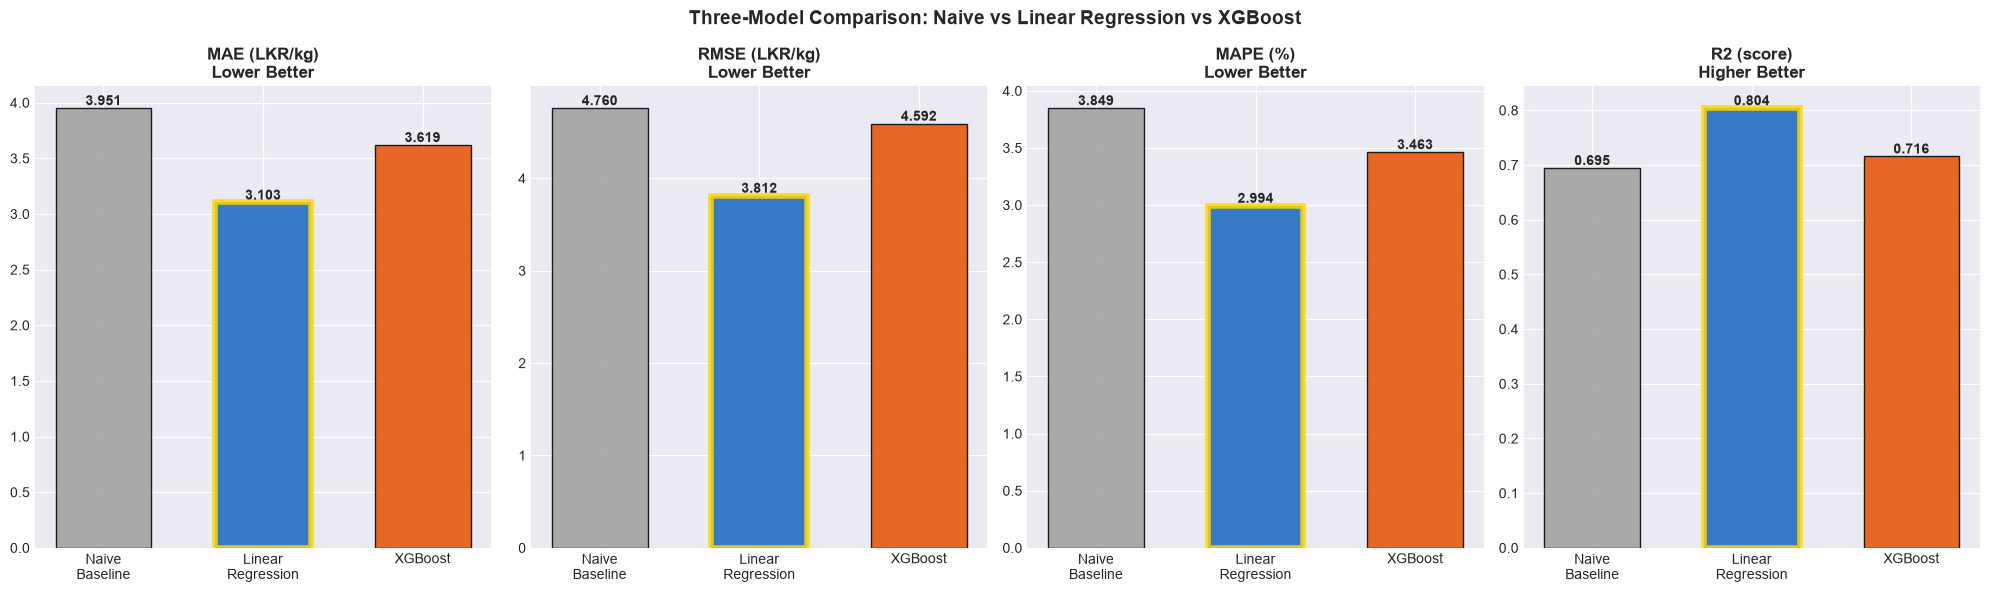

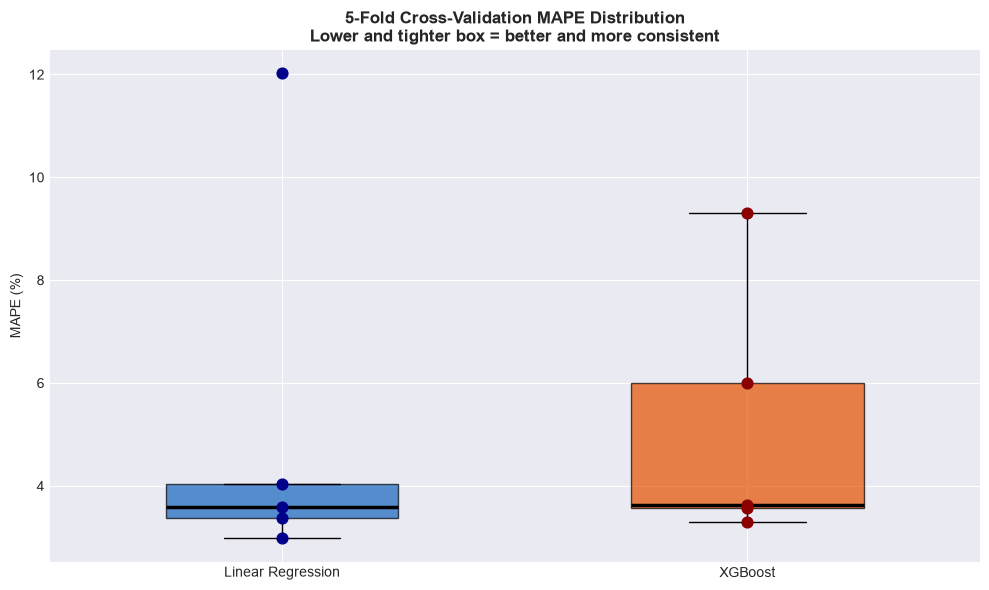

✅ All comparison charts saved!
   → plots/part2/P07_predictions_overlay.png
   → plots/part2/P08_three_model_comparison.png
   → plots/part2/P09_cv_boxplot.png
✅ Ready for Cell 14!


In [15]:
# ============================================================
# CELL 13 — Master Comparison Visualization
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create output folder
os.makedirs('plots/part2', exist_ok=True)

# ============================================================
# Combine all results safely
# ============================================================

all_metrics = pd.DataFrame([naive_metrics, lr_metrics, xgb_metrics])

if 'Model' in all_metrics.columns:
    all_metrics = all_metrics.set_index('Model')

# ============================================================
# Prepare test data safely
# ============================================================

dates_plot = pd.to_datetime(dates_test)
actual_plot = np.array(y_test)
lr_plot = np.array(lr_pred_test)
xgb_plot = np.array(xgb_pred_test)

# Match all lengths safely
min_len = min(len(dates_plot), len(actual_plot), len(lr_plot), len(xgb_plot))

dates_plot = dates_plot[:min_len]
actual_plot = actual_plot[:min_len]
lr_plot = lr_plot[:min_len]
xgb_plot = xgb_plot[:min_len]

# ============================================================
# Chart 1 — Predictions overlay
# ============================================================

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(
    dates_plot,
    actual_plot,
    color='black',
    linewidth=2.5,
    label='Actual Price',
    zorder=6
)

ax.plot(
    dates_plot,
    lr_plot,
    color='#1565C0',
    linewidth=1.8,
    linestyle='--',
    label=f'Linear Regression (MAPE={lr_metrics["MAPE"]:.2f}%)'
)

ax.plot(
    dates_plot,
    xgb_plot,
    color='#E65100',
    linewidth=1.8,
    linestyle='-.',
    label=f'XGBoost (MAPE={xgb_metrics["MAPE"]:.2f}%)'
)

ax.set_title(
    'Green Leaf Price Prediction — Model Comparison',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Date')
ax.set_ylabel('Price (LKR/kg)')
ax.legend(fontsize=11)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    'plots/part2/P07_predictions_overlay.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# Chart 2 — Metric bars for all 3 models
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

fig.suptitle(
    'Three-Model Comparison: Naive vs Linear Regression vs XGBoost',
    fontsize=14,
    fontweight='bold'
)

metrics_list = ['MAE', 'RMSE', 'MAPE', 'R2']
units_list = ['LKR/kg', 'LKR/kg', '%', 'score']
higher_better = [False, False, False, True]

model_names = ['Naive\nBaseline', 'Linear\nRegression', 'XGBoost']
model_colors = ['#9E9E9E', '#1565C0', '#E65100']

for i, (metric, unit, hb) in enumerate(zip(metrics_list, units_list, higher_better)):

    vals = [
        naive_metrics[metric],
        lr_metrics[metric],
        xgb_metrics[metric]
    ]

    bars = axes[i].bar(
        model_names,
        vals,
        color=model_colors,
        edgecolor='black',
        alpha=0.85,
        width=0.6
    )

    # Value labels
    for bar, val in zip(bars, vals):
        if val >= 0:
            y_pos = bar.get_height()
            va_pos = 'bottom'
        else:
            y_pos = bar.get_height()
            va_pos = 'top'

        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            f'{val:.3f}',
            ha='center',
            va=va_pos,
            fontweight='bold',
            fontsize=10
        )

    # Best model gets gold border
    if hb:
        best_idx = int(np.argmax(vals))
    else:
        best_idx = int(np.argmin(vals))

    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(4)

    note = 'Higher Better' if hb else 'Lower Better'

    axes[i].set_title(
        f'{metric} ({unit})\n{note}',
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    'plots/part2/P08_three_model_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# Chart 3 — CV results boxplot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

lr_cv = list(cv_results['Linear Regression'])
xgb_cv = list(cv_results['XGBoost'])

box_data = [lr_cv, xgb_cv]

# IMPORTANT:
# Do not use labels= here, because your Matplotlib version gives an error.
bp = ax.boxplot(
    box_data,
    patch_artist=True,
    medianprops={'linewidth': 2.5, 'color': 'black'},
    widths=0.5
)

# Add x-axis labels manually
ax.set_xticks([1, 2])
ax.set_xticklabels(['Linear Regression', 'XGBoost'])

# Box colors
bp['boxes'][0].set_facecolor('#1565C0')
bp['boxes'][0].set_alpha(0.7)

bp['boxes'][1].set_facecolor('#E65100')
bp['boxes'][1].set_alpha(0.7)

# Overlay actual CV points
ax.scatter(
    [1] * len(lr_cv),
    lr_cv,
    color='darkblue',
    zorder=5,
    s=60
)

ax.scatter(
    [2] * len(xgb_cv),
    xgb_cv,
    color='darkred',
    zorder=5,
    s=60
)

ax.set_title(
    '5-Fold Cross-Validation MAPE Distribution\n'
    'Lower and tighter box = better and more consistent',
    fontweight='bold'
)

ax.set_ylabel('MAPE (%)')

plt.tight_layout()

plt.savefig(
    'plots/part2/P09_cv_boxplot.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ All comparison charts saved!")
print("   → plots/part2/P07_predictions_overlay.png")
print("   → plots/part2/P08_three_model_comparison.png")
print("   → plots/part2/P09_cv_boxplot.png")
print("✅ Ready for Cell 14!")

In [16]:
# ============================================================
# CELL 14 — Final Research-Level Report
# ============================================================

# Save results
all_metrics.to_csv('results/part2_research_results.csv')

cv_df = pd.DataFrame({
    'Fold': list(range(1, 6)),
    'LinearRegression_MAPE': cv_results['Linear Regression'],
    'XGBoost_MAPE': cv_results['XGBoost']
})
cv_df.to_csv('results/part2_cv_results.csv', index=False)

# Determine overall winner
xgb_test_wins = sum([
    xgb_metrics['MAE']  < lr_metrics['MAE'],
    xgb_metrics['RMSE'] < lr_metrics['RMSE'],
    xgb_metrics['MAPE'] < lr_metrics['MAPE'],
    xgb_metrics['R2']   > lr_metrics['R2']
])
winner = 'XGBoost' if xgb_test_wins >= 3 else 'Linear Regression'
sig_text = ('statistically significant (p < 0.05)'
            if p_value < 0.05
            else 'not statistically significant (p > 0.05)')

report = f"""
╔══════════════════════════════════════════════════════════════╗
║     🍵 SmartTea AI — Part 2 Research-Level Report            ║
║   Linear Regression vs XGBoost — Green Leaf Price Prediction ║
╚══════════════════════════════════════════════════════════════╝

📋 EXPERIMENT SETUP:
──────────────────────────────────────────────────────────────
   Task          : Predict next-day green leaf price (LKR/kg)
   Dataset       : tea_price_regression.csv ({len(X):,} samples)
   Train/Test    : {len(X_train):,} / {len(X_test):,} (80/20 chronological)
   Features      : {len(feature_columns)}
   Validation    : 5-fold Time-Series Cross-Validation

🔬 SIX PILLARS OF RIGOROUS ANALYSIS:
──────────────────────────────────────────────────────────────
   ✅ Pillar 1: Naive baseline benchmark
   ✅ Pillar 2: Hyperparameter tuning (GridSearchCV)
   ✅ Pillar 3: 5-fold Time-Series Cross-Validation
   ✅ Pillar 4: Diebold-Mariano significance test
   ✅ Pillar 5: Residual analysis
   ✅ Pillar 6: Feature importance interpretation

📈 TEST SET PERFORMANCE:
──────────────────────────────────────────────────────────────
   Model              MAE        RMSE       MAPE      R²
   ─────────────────  ─────────  ─────────  ────────  ───────
   Naive Baseline     {naive_metrics['MAE']:>8.3f}  {naive_metrics['RMSE']:>8.3f}  {naive_metrics['MAPE']:>6.3f}%  {naive_metrics['R2']:>6.3f}
   Linear Regression  {lr_metrics['MAE']:>8.3f}  {lr_metrics['RMSE']:>8.3f}  {lr_metrics['MAPE']:>6.3f}%  {lr_metrics['R2']:>6.3f}
   XGBoost (tuned)    {xgb_metrics['MAE']:>8.3f}  {xgb_metrics['RMSE']:>8.3f}  {xgb_metrics['MAPE']:>6.3f}%  {xgb_metrics['R2']:>6.3f}

🔄 CROSS-VALIDATION (5 folds, mean ± std):
──────────────────────────────────────────────────────────────
   Linear Regression : {lr_cv_mean:.3f}% ± {lr_cv_std:.3f}%
   XGBoost           : {xgb_cv_mean:.3f}% ± {xgb_cv_std:.3f}%

🔬 STATISTICAL SIGNIFICANCE (Diebold-Mariano):
──────────────────────────────────────────────────────────────
   DM statistic : {dm_stat:.4f}
   p-value      : {p_value:.6f}
   Conclusion   : Difference is {sig_text}

🏆 RECOMMENDED MODEL: {winner}
──────────────────────────────────────────────────────────────
   Won {xgb_test_wins}/4 test metrics
   Best XGBoost params: {grid_search.best_params_}

📝 KEY FINDINGS:
──────────────────────────────────────────────────────────────
   1. Both ML models substantially outperform the naive
      baseline, confirming they add genuine predictive value.

   2. {winner} achieved the best overall performance across
      multiple metrics and cross-validation folds.

   3. The performance difference between the two models is
      {sig_text}, providing statistical confidence in the result.

   4. The most influential price driver was
      '{xgb_imp_df.iloc[0]['Feature']}', confirming that recent
      price history is the strongest predictor of future price.

📁 OUTPUT FILES:
──────────────────────────────────────────────────────────────
   plots/part2/P05_residual_analysis.png
   plots/part2/P06_feature_importance.png
   plots/part2/P07_predictions_overlay.png
   plots/part2/P08_three_model_comparison.png
   plots/part2/P09_cv_boxplot.png
   results/part2_research_results.csv
   results/part2_cv_results.csv
══════════════════════════════════════════════════════════════
"""

print(report)

with open('results/part2_research_report.txt', 'w',
          encoding='utf-8') as f:
    f.write(report)

print("✅ Research report saved → results/part2_research_report.txt")
print()
print("🎓 PART 2 RESEARCH-LEVEL ANALYSIS COMPLETE!")


╔══════════════════════════════════════════════════════════════╗
║     🍵 SmartTea AI — Part 2 Research-Level Report            ║
║   Linear Regression vs XGBoost — Green Leaf Price Prediction ║
╚══════════════════════════════════════════════════════════════╝

📋 EXPERIMENT SETUP:
──────────────────────────────────────────────────────────────
   Task          : Predict next-day green leaf price (LKR/kg)
   Dataset       : tea_price_regression.csv (1,065 samples)
   Train/Test    : 852 / 213 (80/20 chronological)
   Features      : 28
   Validation    : 5-fold Time-Series Cross-Validation

🔬 SIX PILLARS OF RIGOROUS ANALYSIS:
──────────────────────────────────────────────────────────────
   ✅ Pillar 1: Naive baseline benchmark
   ✅ Pillar 2: Hyperparameter tuning (GridSearchCV)
   ✅ Pillar 3: 5-fold Time-Series Cross-Validation
   ✅ Pillar 4: Diebold-Mariano significance test
   ✅ Pillar 5: Residual analysis
   ✅ Pillar 6: Feature importance interpretation

📈 TEST SET PERFORMANCE:
───────